In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('ranks.csv')
df[df['rank'] != 1.0][-10:]

,checkpoint,rank,compute_equiv_rank,mean,stddev,iters,elapsed_seconds
133,checkpoint-00133-b4100aed,7.94,4.67,7.61957,0.28535,9,837.983828
134,checkpoint-00134-4343df56,8.00,4.67,7.74312,0.21762,9,846.213059
135,checkpoint-00135-b77f006b,8.00,4.67,7.74312,0.21762,9,751.480258
136,checkpoint-00136-821ed147,7.88,4.67,7.58138,0.30130,9,203.881439
137,checkpoint-00137-fe781108,7.88,4.67,7.58138,0.30130,9,214.208991
138,checkpoint-00138-025ee6fd,7.88,4.67,7.58138,0.30130,9,220.845867
139,checkpoint-00139-a9bef3e5,8.00,4.67,7.74312,0.21762,9,842.069205
140,checkpoint-00140-581a09ad,8.00,4.67,7.74312,0.21762,9,951.903121
141,checkpoint-00141-5c36a3f5,8.00,4.67,7.74312,0.21762,9,962.908924
142,checkpoint-00142-80bef072,7.94,4.67,7.61957,0.28535,9,712.549498


In [2]:
print(sum(df['elapsed_seconds']) / 60.0 / 60.0)

5.989787704144722


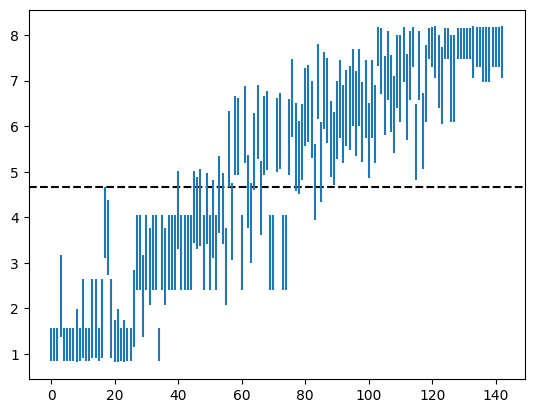

In [3]:
xs = np.array(df.index)
ys_m = np.array(df['mean'])
ys_s = np.array(df['stddev'])

plt.axhline(y=df['compute_equiv_rank'][0], color='black', linestyle='--')
plt.errorbar(xs, ys_m, yerr=2.0*ys_s, linestyle='none')
plt.show()

This plot shows the relative strength of the different checkpoints when playing in "intuition mode" (i.e. no search, only playing argmax of the policy) versus an MCTS. The MCTS plays with $10^y$ rollouts and the dashed line is the MCTS setting that uses a similar amount of computation time as the neural net for picking a move (albeit on the CPU rather than the GPU). Due to computational constraints, a limit of $10^8$ rollouts was used.